# **Challenge Telecom X parte 2**

- *En este desafío, se llevará a cabo un análisis enfocado en la evasión de clientes, desarrollando un modelo predictivo para abordar este problema. Se emplearán técnicas como ingeniería de características (feature engineering) y codificación de variables (feature encoding) mediante métodos como One-Hot Encoding, entre otros. Estas transformaciones permitirán preparar los datos de manera adecuada para identificar el modelo con los parámetros que mejor se ajusten, logrando así una predicción precisa, limpia y robusta.*

---
En el análisis exploratorio anterior se realizó lo siguiente:

### 1. Extracción y Limpieza de Datos
- Importación de datos desde archivo JSON
- Normalización de estructura de datos anidados
- Tratamiento de valores nulos y duplicados
- Estandarización de variables categóricas
- Conversión de tipos de datos

### 2. Análisis Exploratorio
- Estadística descriptiva
- Visualizaciones de distribuciones
- Análisis de proporciones
- Matriz de correlación

### 3. Análisis Estadístico Inferencial
- Test de Shapiro-Wilk para verificar normalidad
- Test de Mann-Whitney U para comparación de medianas
- Test de Chi-cuadrado para asociación entre variables categóricas

## Principales Hallazgos

1. **Cargos mensuales**: Los clientes que abandonan pagan significativamente más que los clientes actuales.

2. **Antigüedad**: Los clientes nuevos tienen mayor probabilidad de abandono que los clientes con mayor tiempo en la empresa.

3. **Tipo de contrato**: Existe una fuerte relación entre el tipo de contrato y la tasa de churn:
   - Mes a mes: 42.7%
   - Anual: 11.3%
   - Bianual: 2.8%

## Tecnologías Utilizadas

- Python 3.x
- pandas
- numpy
- matplotlib
- seaborn
- scipy
- requests

## Estructura del Análisis

El notebook está organizado en las siguientes secciones:

1. Bibliotecas
2. Extracción de datos
3. Transformación de datos
4. Análisis descriptivo
5. Análisis inferencial
6. Informe final con recomendaciones

## Resultados

La tasa de churn actual es del 26.6%. El análisis identifica un perfil de cliente de alto riesgo caracterizado por ser nuevo, tener cargos mensuales elevados y contar con contrato mes a mes. Las recomendaciones se enfocan en mejorar la percepción de valor, fortalecer el onboarding de nuevos clientes e incentivar contratos de largo plazo.

## *Importando bibliotecas*

In [7]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

## *Leyendo el DataFrame*

In [8]:
data = pd.read_csv ('data_limpia.csv', sep= ',')
data.sample(5)

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total,account_charges_day
5236,7395-XWZOY,0,1,0,0,0,20,0,0,DSL,...,1,1,1,0,Month-to-month,1,Credit card (automatic),55.00,1165.55,1.833333
6831,9717-IOAAF,0,1,0,0,1,27,1,1,0,...,0,0,0,0,Two year,1,Credit card (automatic),25.85,788.55,0.861667
3987,5639-NTUPK,0,1,0,0,1,13,1,0,DSL,...,0,0,0,0,Month-to-month,1,Credit card (automatic),52.10,670.65,1.736667
42,0071-NDAFP,0,1,0,1,1,25,1,1,0,...,0,0,0,0,Two year,0,Credit card (automatic),25.50,630.60,0.850000
2293,3284-SVCRO,0,0,0,1,0,45,1,1,0,...,0,0,0,0,Two year,0,Mailed check,25.50,1121.05,0.850000


In [9]:
# ¿Modelo de regresión o clasificación?
data['churn'].nunique()

2

In [10]:
data.churn.unique()

array([0, 1])

# *Problema de clasificación*

## *Bibliotecas para modelo de clasificación*

In [11]:
# Métricas de evaluación
from yellowbrick.classifier import ConfusionMatrix, ClassificationReport, ROCAUC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Modelos de clasificación
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [12]:
# Onehot encoding
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import make_column_transformer

In [13]:
data = data.drop ('customerid', axis=1)

## *Análisis exploratorio*

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   churn                      7032 non-null   int64  
 1   customer_gender            7032 non-null   int64  
 2   customer_seniorcitizen     7032 non-null   int64  
 3   customer_partner           7032 non-null   int64  
 4   customer_dependents        7032 non-null   int64  
 5   customer_tenure            7032 non-null   int64  
 6   phone_phoneservice         7032 non-null   int64  
 7   phone_multiplelines        7032 non-null   int64  
 8   internet_internetservice   7032 non-null   object 
 9   internet_onlinesecurity    7032 non-null   int64  
 10  internet_onlinebackup      7032 non-null   int64  
 11  internet_deviceprotection  7032 non-null   int64  
 12  internet_techsupport       7032 non-null   int64  
 13  internet_streamingtv       7032 non-null   int64

In [15]:
# Número de categorías por variable para saber cuántas columnas se crearán al aplicar onehot encoding
data[['internet_internetservice', 'account_contract', 'account_paymentmethod']].nunique()

internet_internetservice    3
account_contract            3
account_paymentmethod       4
dtype: int64

In [16]:
data.shape[1]

21

## *One-Hot Encoder*

*Se debe realizar la separación de las variables predictoras (X) y la variable objetivo (y) antes de aplicar One-Hot Encoding, para evitar que la transformación se aplique sobre la variable objetivo.*

In [17]:
# Realizamos la separación entre variable objetivo y variables predictoras 
X = data.drop(columns='churn', axis=1)

y = data['churn']

In [18]:
one_hot = make_column_transformer ((OneHotEncoder(drop='if_binary'),
                                    X.select_dtypes(include='object').columns.to_list()),
                                    (MinMaxScaler(), X.select_dtypes(include=['float64', 'int64']).columns.to_list()),
                                remainder='passthrough',
                                sparse_threshold=0)

### *Aplicando One-Hot Encoder a las variables predictoras (X)*

In [19]:
X = one_hot.fit_transform(X)
X = pd.DataFrame(X, columns=one_hot.get_feature_names_out())
display (X.sample(5))
print (X.shape)


,onehotencoder__internet_internetservice_0,onehotencoder__internet_internetservice_DSL,onehotencoder__internet_internetservice_Fiber optic,onehotencoder__account_contract_Month-to-month,onehotencoder__account_contract_One year,onehotencoder__account_contract_Two year,onehotencoder__account_paymentmethod_Bank transfer (automatic),onehotencoder__account_paymentmethod_Credit card (automatic),onehotencoder__account_paymentmethod_Electronic check,onehotencoder__account_paymentmethod_Mailed check,...,minmaxscaler__internet_onlinesecurity,minmaxscaler__internet_onlinebackup,minmaxscaler__internet_deviceprotection,minmaxscaler__internet_techsupport,minmaxscaler__internet_streamingtv,minmaxscaler__internet_streamingmovies,minmaxscaler__account_paperlessbilling,minmaxscaler__account_charges_monthly,minmaxscaler__account_charges_total,minmaxscaler__account_charges_day
2648,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.018408,0.075185,0.018408
1487,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.706965,0.735039,0.706965
2655,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.575124,0.314840,0.575124
1660,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.015423,0.127060,0.015423
5918,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.617413,0.576841,0.617413


(7032, 27)


## *Entrenamiento y prueba*

In [20]:
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42)

# *Funciones de métricas y matriz confusión*

In [21]:
def calcular_metricas (y_prueba, y_predicho):
    Accuracy = accuracy_score (y_prueba, y_predicho)
    Precision = precision_score (y_prueba, y_predicho)
    Recall = recall_score (y_prueba, y_predicho)
    F1 = f1_score (y_prueba, y_predicho)
    return {'Accuracy': Accuracy,
            'Precision': Precision,
            'Recall': Recall,
            'F1': F1}

def calcular_confusion_matrix (y_prueba, y_predicho):
    cm = ConfusionMatrixDisplay.from_predictions (y_prueba, y_predicho, display_labels=['No evade', 'Evade'])
    plt.title ('Matriz de confusión')
    plt.show()

# *Modelo Baseline (Dummy)*

In [22]:
modelo_dummy = DummyClassifier (random_state=42)
modelo_dummy.fit (X_train, y_train)
y_pred_dummy = modelo_dummy.predict (X_test)

In [23]:
calcular_metricas (y_test, y_pred_dummy)

c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'Accuracy': 0.7341862117981521, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

## *Matriz de confusión*

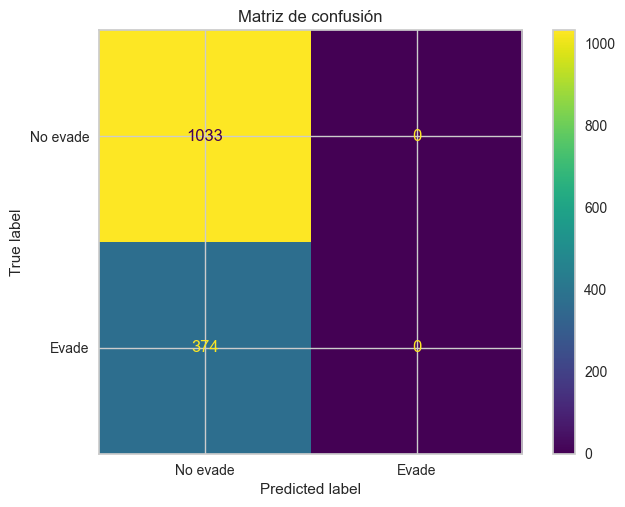

In [24]:
calcular_confusion_matrix (y_test, y_pred_dummy)

## *Resultados del Modelo Baseline (Dummy)*

- Como se puede observar en la matriz de confusión anterior y las métricas, el modelo no predice correctamente, dado que las clases están desbalanceadas. El modelo solo aprende de la clase mayoritaria (clientes que no evaden), ignorando a los que sí lo hacen.

# *Modelo Random Forest sin ajuste de hiperparámetros*

In [25]:
modelo_random_forest_base = RandomForestClassifier (random_state=42,
                                                    bootstrap=True,
                                                    max_depth= 5,
                                                    class_weight='balanced')

In [26]:
modelo_random_forest_base.fit (X_train, y_train)
y_pred_forest_base = modelo_random_forest_base.predict (X_test)

## *Métricas*

In [27]:
calcular_metricas (y_test, y_pred_forest_base)

{'Accuracy': 0.7327647476901208,
 'Precision': 0.4983164983164983,
 'Recall': 0.7914438502673797,
 'F1': 0.6115702479338843}

## *Matriz de confusión*

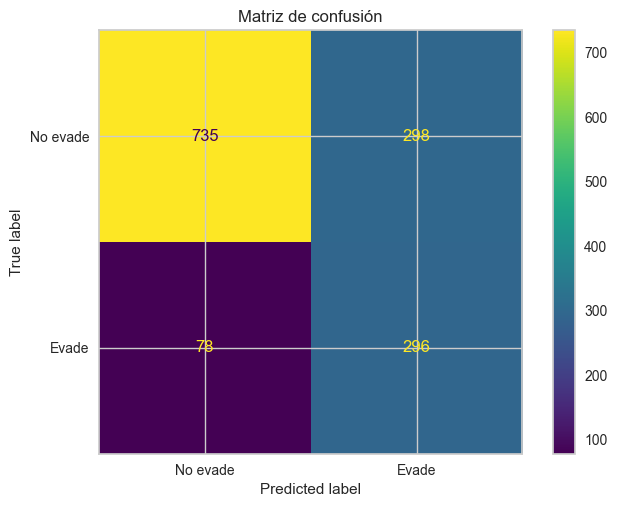

In [32]:
calcular_confusion_matrix (y_test, y_pred_forest_base)

# *Modelo XGBoost sin ajuste de hiperparámetros*

In [28]:
modelo_xgb_base = XGBClassifier (random_state=42,
                                device='cuda',
                                max_depth=5,
                                n_estimators=100,
                                scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]))

In [29]:
modelo_xgb_base.fit (X_train, y_train)
y_pred_xgb_base = modelo_xgb_base.predict (X_test)

c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:751: UserWarning: [00:35:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


## *Métricas*

In [30]:
calcular_metricas (y_test, y_pred_xgb_base)

{'Accuracy': 0.7434257285003554,
 'Precision': 0.5130784708249497,
 'Recall': 0.6818181818181818,
 'F1': 0.5855338691159586}

## *Matriz de confusión*

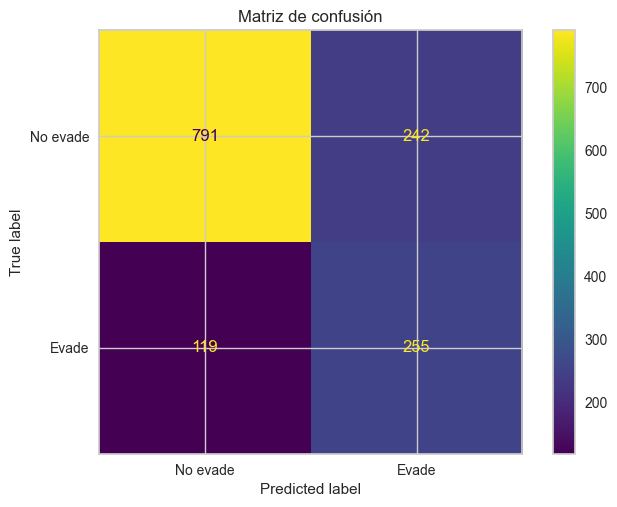

In [31]:
calcular_confusion_matrix (y_test, y_pred_xgb_base)

# *Selección de features (Feature Importance)*

## *RandomForest*

In [42]:
features_forest = modelo_random_forest_base.feature_importances_
features_forest_df = pd.DataFrame ({'Features': one_hot.get_feature_names_out(),
                                     'Importancia': features_forest*100}).sort_values ('Importancia')[::-1]

In [ ]:
resultados_features_forest = pd.DataFrame (index= ['Accuracy', 'Precision', 'Recall', 'F1-Score'])
modelo_random_forest_features = RandomForestClassifier (random_state=42,
                                                    bootstrap=True,
                                                    class_weight='balanced')

ct_features = np.arange (16,22,1)

for i in ct_features:
    selected_features = features_forest_df['Features'].values[:i]
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    modelo_random_forest_features.fit (X_train_selected, y_train)
    y_pred_forest_features = modelo_random_forest_features.predict (X_test_selected)
    metricas = calcular_metricas (y_test, y_pred_forest_features)
    resultados_features_forest[i] = list (metricas.values())

resultados_features_forest

,16,17,18,19,20,21
Accuracy,0.772566,0.773276,0.775409,0.782516,0.776830,0.777541
Precision,0.585443,0.588997,0.593548,0.609677,0.596154,0.603390
Recall,0.494652,0.486631,0.491979,0.505348,0.497326,0.475936
F1-Score,0.536232,0.532943,0.538012,0.552632,0.542274,0.532138


### *19 variables óptimas para Random Forest*

## *XGBoost*

In [41]:
features_xgboost =modelo_xgb_base.feature_importances_
features_xgboost_df = pd.DataFrame ({'Features': one_hot.get_feature_names_out(),
                                     'Importancia': features_xgboost*100}).sort_values ('Importancia')[::-1]

In [59]:
resultados_features_xgboost = pd.DataFrame (index= ['Accuracy', 'Precision', 'Recall', 'F1-Score'])
modelo_xgboost_features = XGBClassifier (random_state=42)

ct_features = np.arange (16, 22,1)

for i in ct_features:
    selected_features = features_forest_df['Features'].values[:i]
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]
    modelo_xgboost_features.fit (X_train_selected, y_train)
    y_pred_xgboost_features = modelo_xgboost_features.predict (X_test_selected)
    metricas = calcular_metricas (y_test, y_pred_xgboost_features)
    resultados_features_xgboost[i] = list (metricas.values())

resultados_features_xgboost

,16,17,18,19,20,21
Accuracy,0.768301,0.784648,0.766880,0.769723,0.772566,0.763326
Precision,0.573171,0.610592,0.569697,0.574405,0.581818,0.559767
Recall,0.502674,0.524064,0.502674,0.516043,0.513369,0.513369
F1-Score,0.535613,0.564029,0.534091,0.543662,0.545455,0.535565


### *17 variables óptimas para XGBoost*

# *Promedio de variables óptimas*

- Dado que el número de variables óptimas para Random Forest es 19 y para XGBoost es 17, se utilizará el promedio de ambas: **18 variables**. La diferencia entre ambos modelos no es significativa, por lo que este promedio resulta un criterio razonable para la selección de features.

# **Optimización de hiperparámetros**

## *Bibliotecas*

In [61]:
from sklearn.model_selection import GridSearchCV

## *Features seleccionadas*

In [63]:
# Para este caso no importa si es de random forest o xgboost, ya que las variables son las mismas
features = X[features_forest_df['Features'].values[:18]]

In [67]:
kfold = StratifiedKFold (n_splits=5, shuffle=True, random_state=42)

## *Random Forest*

In [65]:
X_train, X_test, y_train, y_test = train_test_split (features, y, test_size=0.2, random_state=42)

In [66]:
param_grid_forest = {
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [1, 2, 13],
    'min_samples_split': [2, 4, 6],
    'n_estimators': [100, 150, 200]
}

In [71]:
modelo_optimo_forest = GridSearchCV (RandomForestClassifier (random_state=42, bootstrap=True, class_weight='balanced'),
                                    param_grid=param_grid_forest,
                                    cv=kfold,
                                    scoring= ['accuracy', 'precision', 'recall', 'f1'],
                                    refit= 'recall',
                                    n_jobs=-1)

modelo_optimo_forest.fit (X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], 'n_estimators': [100, 150, ...]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,-1
,refit,'recall'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


## *XGBoost*

In [72]:
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}


In [73]:
modelo_optimo_xgb = GridSearchCV (XGBClassifier (random_state=42,
                                                  device='cuda',
                                                  scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1])),
                                  param_grid=param_grid_xgb,
                                  cv=kfold,
                                  scoring= ['accuracy', 'precision', 'recall', 'f1'],
                                  refit= 'recall',
                                  n_jobs=1)

modelo_optimo_xgb.fit (X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 150, ...], 'subsample': [0.8, 1.0]}"
,scoring,"['accuracy', 'precision', ...]"
,n_jobs,1
,refit,'recall'
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


# *¿Qué modelo es mejor?*

## *Evaluando en test...*

In [76]:
y_pred_forest_opt = modelo_optimo_forest.predict (X_test)
y_pred_xgb_opt = modelo_optimo_xgb.predict (X_test)

In [77]:
comparacion = pd.DataFrame({
    'Random Forest': calcular_metricas(y_test, y_pred_forest_opt),
    'XGBoost': calcular_metricas(y_test, y_pred_xgb_opt)
})
comparacion

,Random Forest,XGBoost
Accuracy,0.729211,0.724947
Precision,0.494078,0.489185
Recall,0.780749,0.786096
F1,0.605181,0.603077


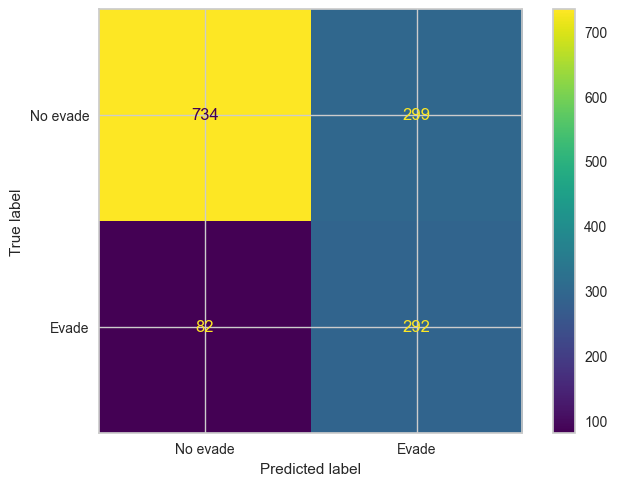

In [89]:
ConfusionMatrixDisplay.from_predictions (y_test, y_pred_forest_opt, display_labels=['No evade', 'Evade'])

## *Evaluando en validación cruzada (train)...*

In [83]:
best_idx_forest = modelo_optimo_forest.best_index_
best_idx_xgb = modelo_optimo_xgb.best_index_

comparacion_2 = pd.DataFrame({
    'Random Forest': {
        'Accuracy': modelo_optimo_forest.cv_results_['mean_test_accuracy'][best_idx_forest],
        'Precision': modelo_optimo_forest.cv_results_['mean_test_precision'][best_idx_forest],
        'Recall': modelo_optimo_forest.cv_results_['mean_test_recall'][best_idx_forest],
        'F1': modelo_optimo_forest.cv_results_['mean_test_f1'][best_idx_forest]
    },
    'XGBoost': {
        'Accuracy': modelo_optimo_xgb.cv_results_['mean_test_accuracy'][best_idx_xgb],
        'Precision': modelo_optimo_xgb.cv_results_['mean_test_precision'][best_idx_xgb],
        'Recall': modelo_optimo_xgb.cv_results_['mean_test_recall'][best_idx_xgb],
        'F1': modelo_optimo_xgb.cv_results_['mean_test_f1'][best_idx_xgb]
    }
})
comparacion_2

,Random Forest,XGBoost
Accuracy,0.753956,0.737956
Precision,0.524083,0.504426
Recall,0.815385,0.818729
F1,0.638007,0.624177


# *Guardando el modelo...*

In [84]:
import pickle

In [85]:
features_seleccionadas = features_forest_df['Features'].values[:18]

paquete = {
    'one_hot': one_hot,
    'features': features_seleccionadas,
    'modelo_random_forest': modelo_optimo_forest.best_estimator_,
}

with open ('modelo_telecom.pkl', 'wb') as file:
    pickle.dump (paquete, file)

# *Modelo ganador: Random Forest*

# *Exportación del modelo (Pipeline)*

Para reutilizar el modelo en otro notebook o en producción, se empaqueta el transformador, las features seleccionadas y el modelo ganador en un solo archivo `.pkl`.

### Guardar el modelo

```python
import pickle

features_seleccionadas = features_forest_df['Features'].values[:18]

paquete = {
    'one_hot': one_hot,                        # el transformador
    'features': features_seleccionadas,         # las 18 columnas
    'modelo': modelo_optimo_forest.best_estimator_  # el modelo ganador
}

with open('modelo_churn.pkl', 'wb') as f:
    pickle.dump(paquete, f)
```

### Cargar y usar el modelo en otro notebook

```python
import pickle
import pandas as pd

# Cargar todo
with open('modelo_churn.pkl', 'rb') as f:
    paquete = pickle.load(f)

# Leer datos nuevos
datos_nuevos = pd.read_csv('nuevos_clientes.csv')
datos_nuevos = datos_nuevos.drop('customerid', axis=1)

# Aplicar las mismas transformaciones
X_nuevo = paquete['one_hot'].transform(datos_nuevos)
X_nuevo = pd.DataFrame(X_nuevo, columns=paquete['one_hot'].get_feature_names_out())

# Seleccionar las mismas 18 features
X_nuevo = X_nuevo[paquete['features']]

# Predecir
predicciones = paquete['modelo'].predict(X_nuevo)
```

``` python
# Ver las llaves del diccionario
print(paquete.keys())
# → dict_keys(['one_hot', 'features', 'modelo_random_forest'])
```